# Import Library

In [1]:
import math
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Load Data

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
df = pd.read_csv("/content/drive/MyDrive/datasets/open-meteo-13.67N100.49E5m.csv", skiprows=3)

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
df.head()

,time,temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),rain (mm),vapour_pressure_deficit (kPa),et0_fao_evapotranspiration (mm),cloud_cover_high (%),cloud_cover_mid (%),cloud_cover_low (%),surface_pressure (hPa),pressure_msl (hPa),weather_code (wmo code),wind_gusts_10m (km/h),wind_direction_10m (°),wind_direction_100m (°),wind_speed_100m (km/h),wind_speed_10m (km/h),soil_moisture_100_to_255cm (m³/m³),soil_moisture_28_to_100cm (m³/m³),soil_moisture_7_to_28cm (m³/m³),soil_moisture_0_to_7cm (m³/m³),soil_temperature_100_to_255cm (°C),soil_temperature_28_to_100cm (°C),soil_temperature_0_to_7cm (°C),soil_temperature_7_to_28cm (°C),is_day ()
0,2000-01-28T00:00,23.1,54,13.2,22.5,0.0,1.31,0.07,96,0,0,1014.6,1015.2,3,19.8,50,55,22.5,10.7,0.464,0.351,0.291,0.190,28.1,29.4,25.7,29.7,0
1,2000-01-28T01:00,22.4,55,13.0,21.7,0.0,1.21,0.06,97,0,0,1014.7,1015.3,3,20.2,42,48,22.2,10.7,0.464,0.351,0.291,0.190,28.1,29.4,25.0,29.5,0
2,2000-01-28T02:00,21.8,58,13.1,21.2,0.0,1.10,0.06,97,0,0,1014.3,1014.9,3,18.4,35,40,21.7,10.6,0.464,0.351,0.291,0.190,28.1,29.4,24.4,29.3,0
3,2000-01-28T03:00,21.1,60,13.0,20.6,0.0,1.01,0.05,98,0,0,1013.7,1014.3,3,17.3,26,32,20.9,10.0,0.464,0.352,0.291,0.189,28.1,29.4,23.9,29.1,0
4,2000-01-28T04:00,20.5,61,12.8,20.0,0.0,0.93,0.04,100,0,0,1014.2,1014.8,3,16.2,25,29,19.8,9.5,0.464,0.352,0.291,0.189,28.1,29.4,23.3,28.9,0


In [6]:
df.shape

(225360, 28)

In [7]:
df.describe()

,temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),rain (mm),vapour_pressure_deficit (kPa),et0_fao_evapotranspiration (mm),cloud_cover_high (%),cloud_cover_mid (%),cloud_cover_low (%),surface_pressure (hPa),pressure_msl (hPa),weather_code (wmo code),wind_gusts_10m (km/h),wind_direction_10m (°),wind_direction_100m (°),wind_speed_100m (km/h),wind_speed_10m (km/h),soil_moisture_100_to_255cm (m³/m³),soil_moisture_28_to_100cm (m³/m³),soil_moisture_7_to_28cm (m³/m³),soil_moisture_0_to_7cm (m³/m³),soil_temperature_100_to_255cm (°C),soil_temperature_28_to_100cm (°C),soil_temperature_0_to_7cm (°C),soil_temperature_7_to_28cm (°C),is_day ()
count,225360.000000,225360.000000,225360.000000,225360.000000,225360.000000,225360.000000,225360.000000,225360.000000,225360.000000,225360.000000,225360.000000,225360.000000,225360.000000,225360.000000,225360.000000,225360.000000,225360.000000,225360.000000,225360.000000,225360.000000,225360.000000,225360.000000,225360.000000,225360.000000,225360.000000,225360.000000,225360.000000
mean,27.901854,74.167612,22.504497,32.090257,0.150221,1.041507,0.179834,60.203532,24.640526,9.183453,1008.608498,1009.208494,12.067239,19.937704,177.710987,174.758675,14.582265,9.025759,0.414865,0.369898,0.370195,0.341064,29.936952,29.961399,30.052297,30.001167,0.501624
std,2.947579,14.754211,3.060872,3.718988,0.620261,0.730701,0.217758,40.418398,28.548143,15.731962,3.052920,3.052929,20.583739,9.122363,89.470027,87.370698,6.041514,4.161971,0.032846,0.063107,0.073709,0.113081,0.999633,1.473021,3.963263,2.063192,0.499998
min,13.500000,17.000000,3.800000,11.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,998.200000,998.800000,0.000000,0.700000,1.000000,1.000000,0.000000,0.000000,0.338000,0.219000,0.248000,0.133000,27.400000,25.800000,17.400000,22.200000,0.000000
25%,26.000000,64.000000,21.800000,30.500000,0.000000,0.480000,0.010000,13.000000,3.000000,0.000000,1006.400000,1007.000000,1.000000,13.000000,120.000000,109.000000,10.200000,5.900000,0.397000,0.321000,0.297000,0.226000,29.300000,29.000000,27.300000,28.600000,0.000000
50%,27.700000,77.000000,23.600000,32.400000,0.000000,0.840000,0.050000,80.000000,14.000000,3.000000,1008.400000,1009.000000,3.000000,19.100000,189.000000,189.000000,14.700000,8.600000,0.417000,0.356000,0.356000,0.352000,29.800000,29.700000,29.300000,29.700000,1.000000
75%,29.900000,86.000000,24.500000,34.300000,0.000000,1.440000,0.340000,98.000000,34.000000,12.000000,1010.600000,1011.200000,3.000000,25.900000,234.000000,232.000000,18.900000,11.800000,0.437000,0.415000,0.439000,0.447000,30.600000,30.800000,32.100000,31.100000,1.000000
max,39.100000,100.000000,28.000000,44.600000,25.500000,5.200000,0.900000,100.000000,100.000000,100.000000,1023.700000,1024.300000,65.000000,74.200000,360.000000,360.000000,46.300000,30.800000,0.510000,0.520000,0.520000,0.520000,32.900000,35.100000,49.000000,38.000000,1.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225360 entries, 0 to 225359
Data columns (total 28 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   time                                225360 non-null  object 
 1   temperature_2m (°C)                 225360 non-null  float64
 2   relative_humidity_2m (%)            225360 non-null  int64  
 3   dew_point_2m (°C)                   225360 non-null  float64
 4   apparent_temperature (°C)           225360 non-null  float64
 5   rain (mm)                           225360 non-null  float64
 6   vapour_pressure_deficit (kPa)       225360 non-null  float64
 7   et0_fao_evapotranspiration (mm)     225360 non-null  float64
 8   cloud_cover_high (%)                225360 non-null  int64  
 9   cloud_cover_mid (%)                 225360 non-null  int64  
 10  cloud_cover_low (%)                 225360 non-null  int64  
 11  surface_pressure (hPa)    

In [9]:
df['time'] = pd.to_datetime(df['time'])

# Create Dataframe

In [10]:
df_train = df[(df['time'] >= '2014-01-01') & (df['time'] < '2025-01-01')]

In [11]:
df_train.shape

(96432, 28)

# EDA

## Plot Over Time

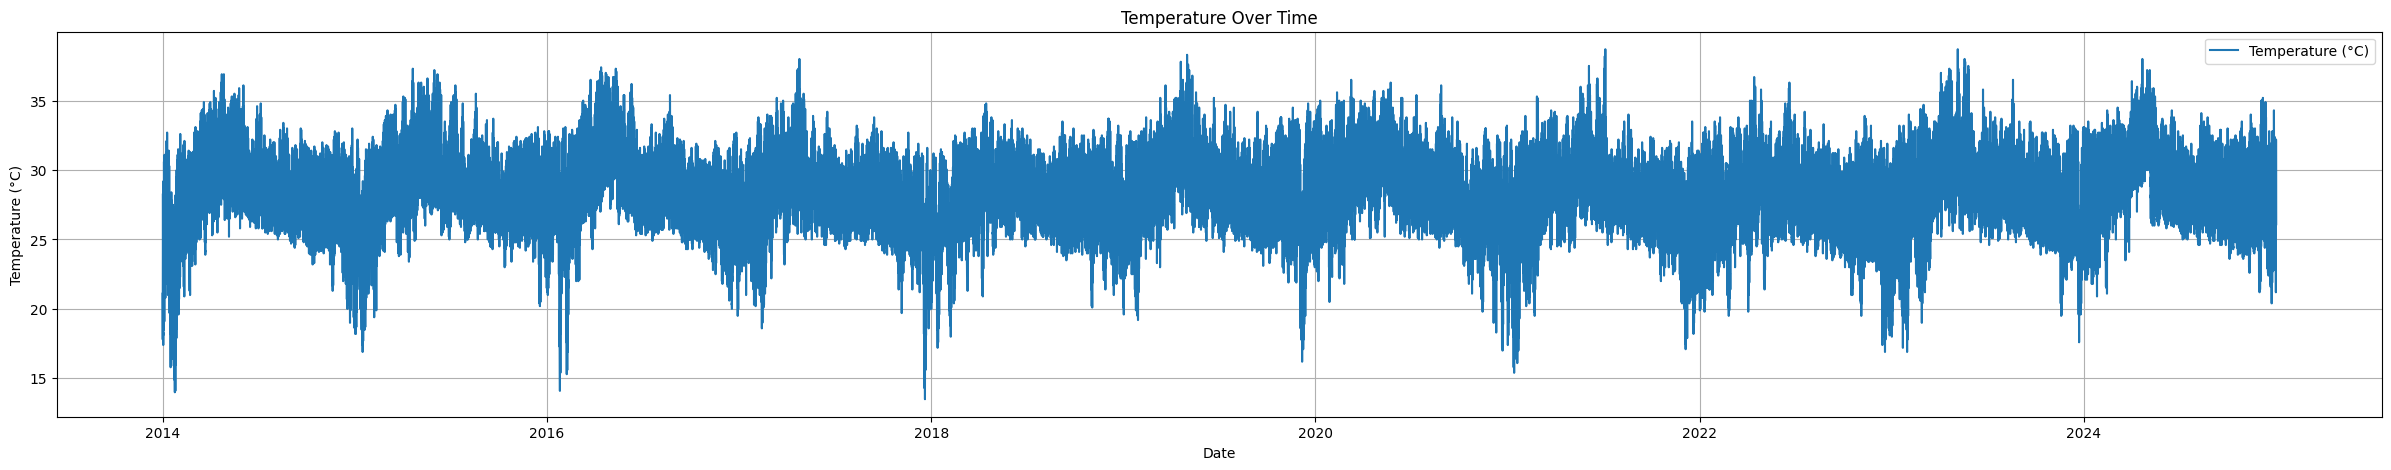

In [12]:
df_train = df_train.sort_values('time')   # just to make sure it's in order

plt.figure(figsize=(30, 5))
plt.plot(df_train['time'], df_train["temperature_2m (°C)"], label='Temperature (°C)')

plt.title('Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

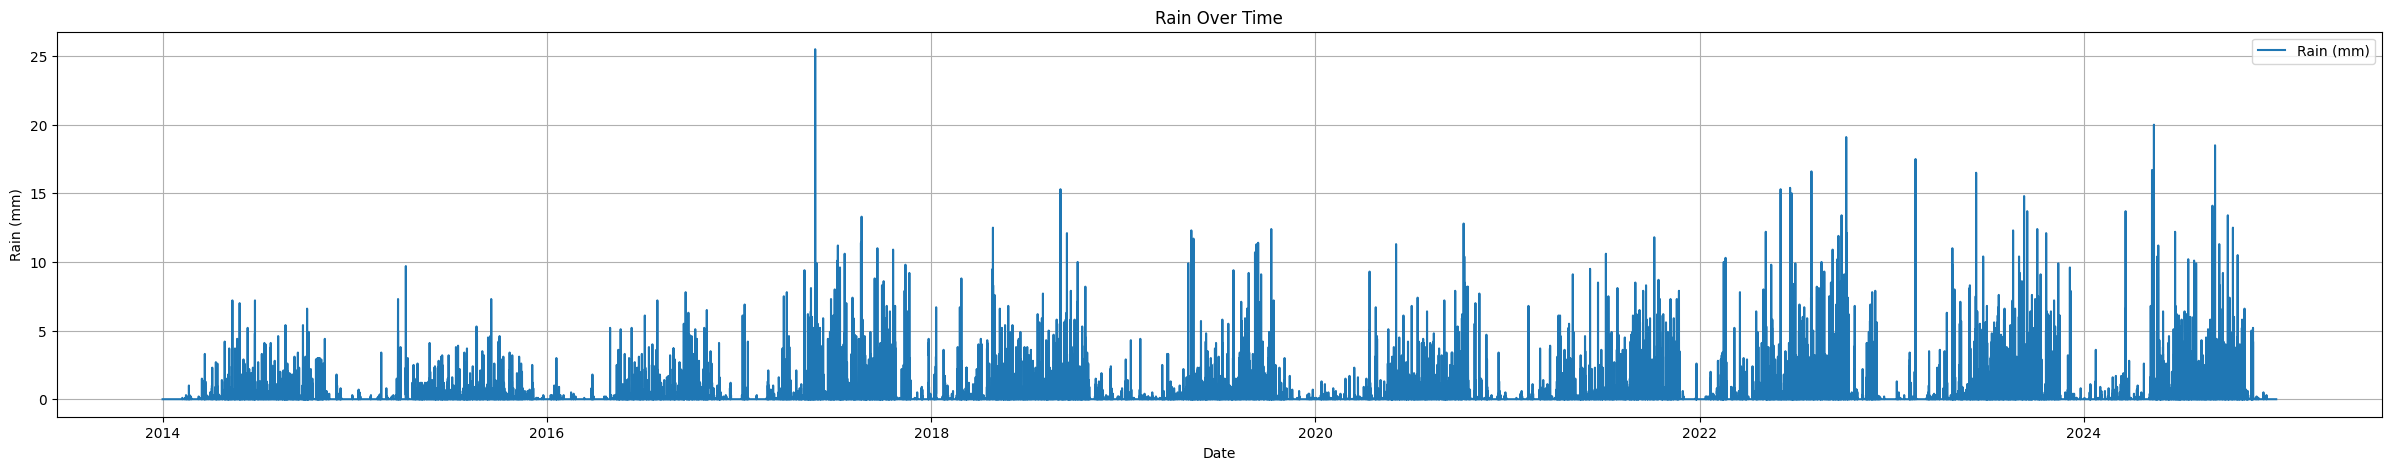

In [13]:
plt.figure(figsize=(30, 5))
plt.plot(df_train['time'], df_train["rain (mm)"], label='Rain (mm)')

plt.title('Rain Over Time')
plt.xlabel('Date')
plt.ylabel('Rain (mm)')
plt.legend()
plt.grid(True)
plt.show()

## Distribution Class Rain

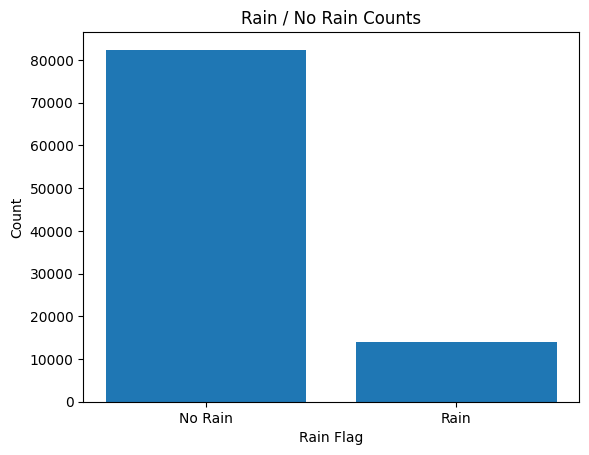

In [14]:
# Create the rain_flag column
df_train['rain_flag'] = (df_train['rain (mm)'] > 0.1).astype(int)

# Count values
counts = df_train['rain_flag'].value_counts().sort_index()

# Plot with pure matplotlib
plt.bar(counts.index, counts.values)
plt.xticks([0, 1], ["No Rain", "Rain"])
plt.xlabel("Rain Flag")
plt.ylabel("Count")
plt.title("Rain / No Rain Counts")
plt.show()

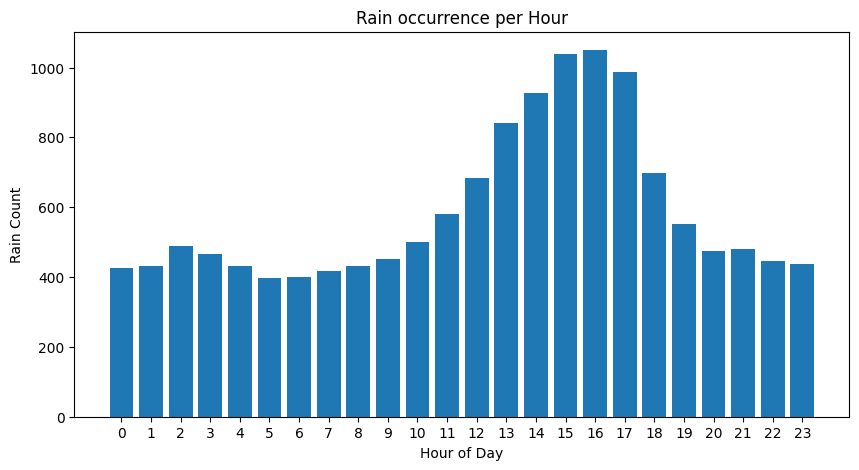

In [15]:
df_train['hour'] = df_train['time'].dt.hour
# Filter rainy rows
rain_df = df_train[df_train['rain_flag'] == 1]

# Count occurrences per hour
counts = rain_df['hour'].value_counts().sort_index()  # ensures hours are in order

# Plot with matplotlib
plt.figure(figsize=(10,5))
plt.bar(counts.index, counts.values)
plt.xlabel("Hour of Day")
plt.ylabel("Rain Count")
plt.title("Rain occurrence per Hour")
plt.xticks(counts.index)  # show all hours
plt.show()

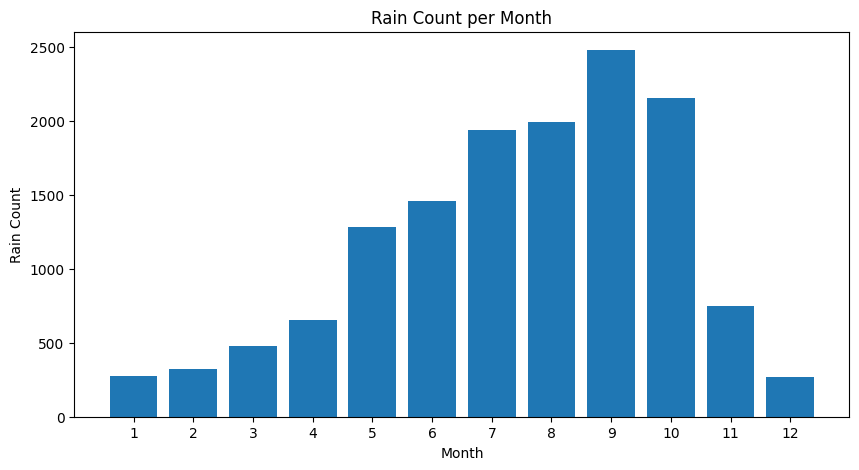

In [16]:
df_train['month'] = df_train['time'].dt.month

# Filter rainy days
rain_df = df_train[df_train['rain_flag'] == 1]

# Count rainy days per month
counts = rain_df['month'].value_counts().sort_index()

# Plot
plt.figure(figsize=(10,5))
plt.bar(counts.index, counts.values)
plt.xlabel("Month")
plt.ylabel("Rain Count")
plt.title("Rain Count per Month")
plt.xticks(counts.index)  # show all months
plt.show()

## Distribution Features

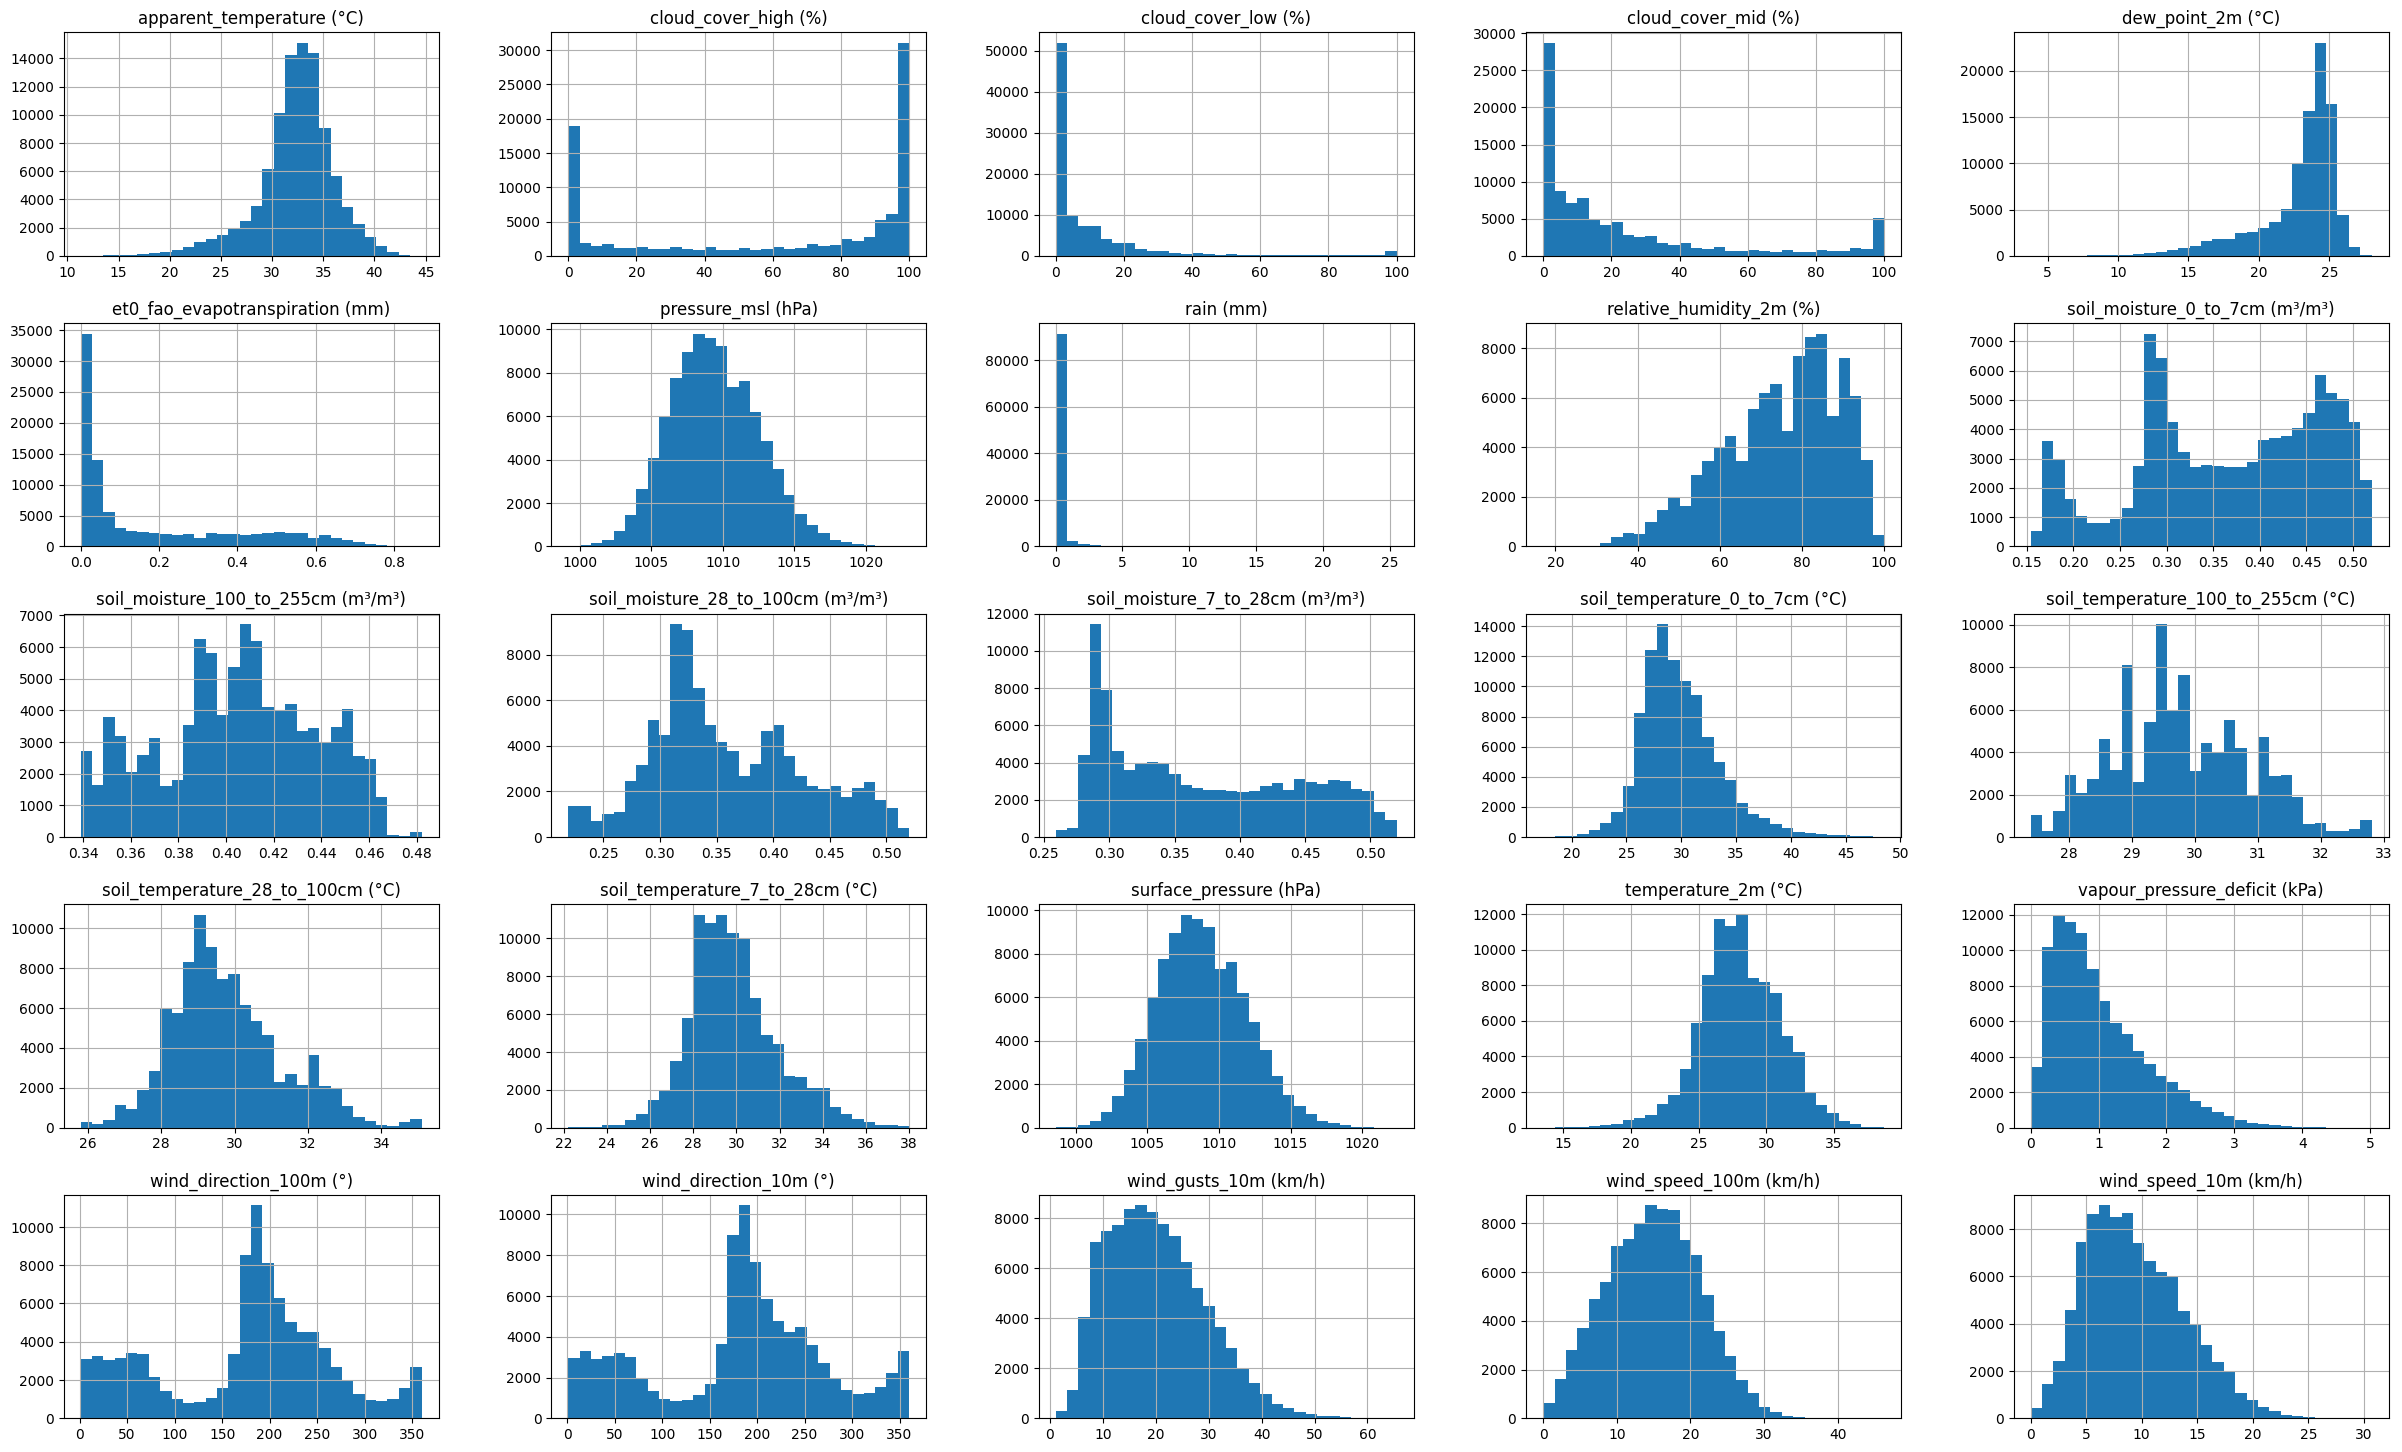

In [17]:
numeric_cols = df_train.select_dtypes(include='number').columns
numeric_cols = numeric_cols.difference(["is_day ()", "rain_flag", "weather_code (wmo code)", "hour", "month"])

df_train[numeric_cols].hist(bins=30, figsize=(30,18))
plt.show()

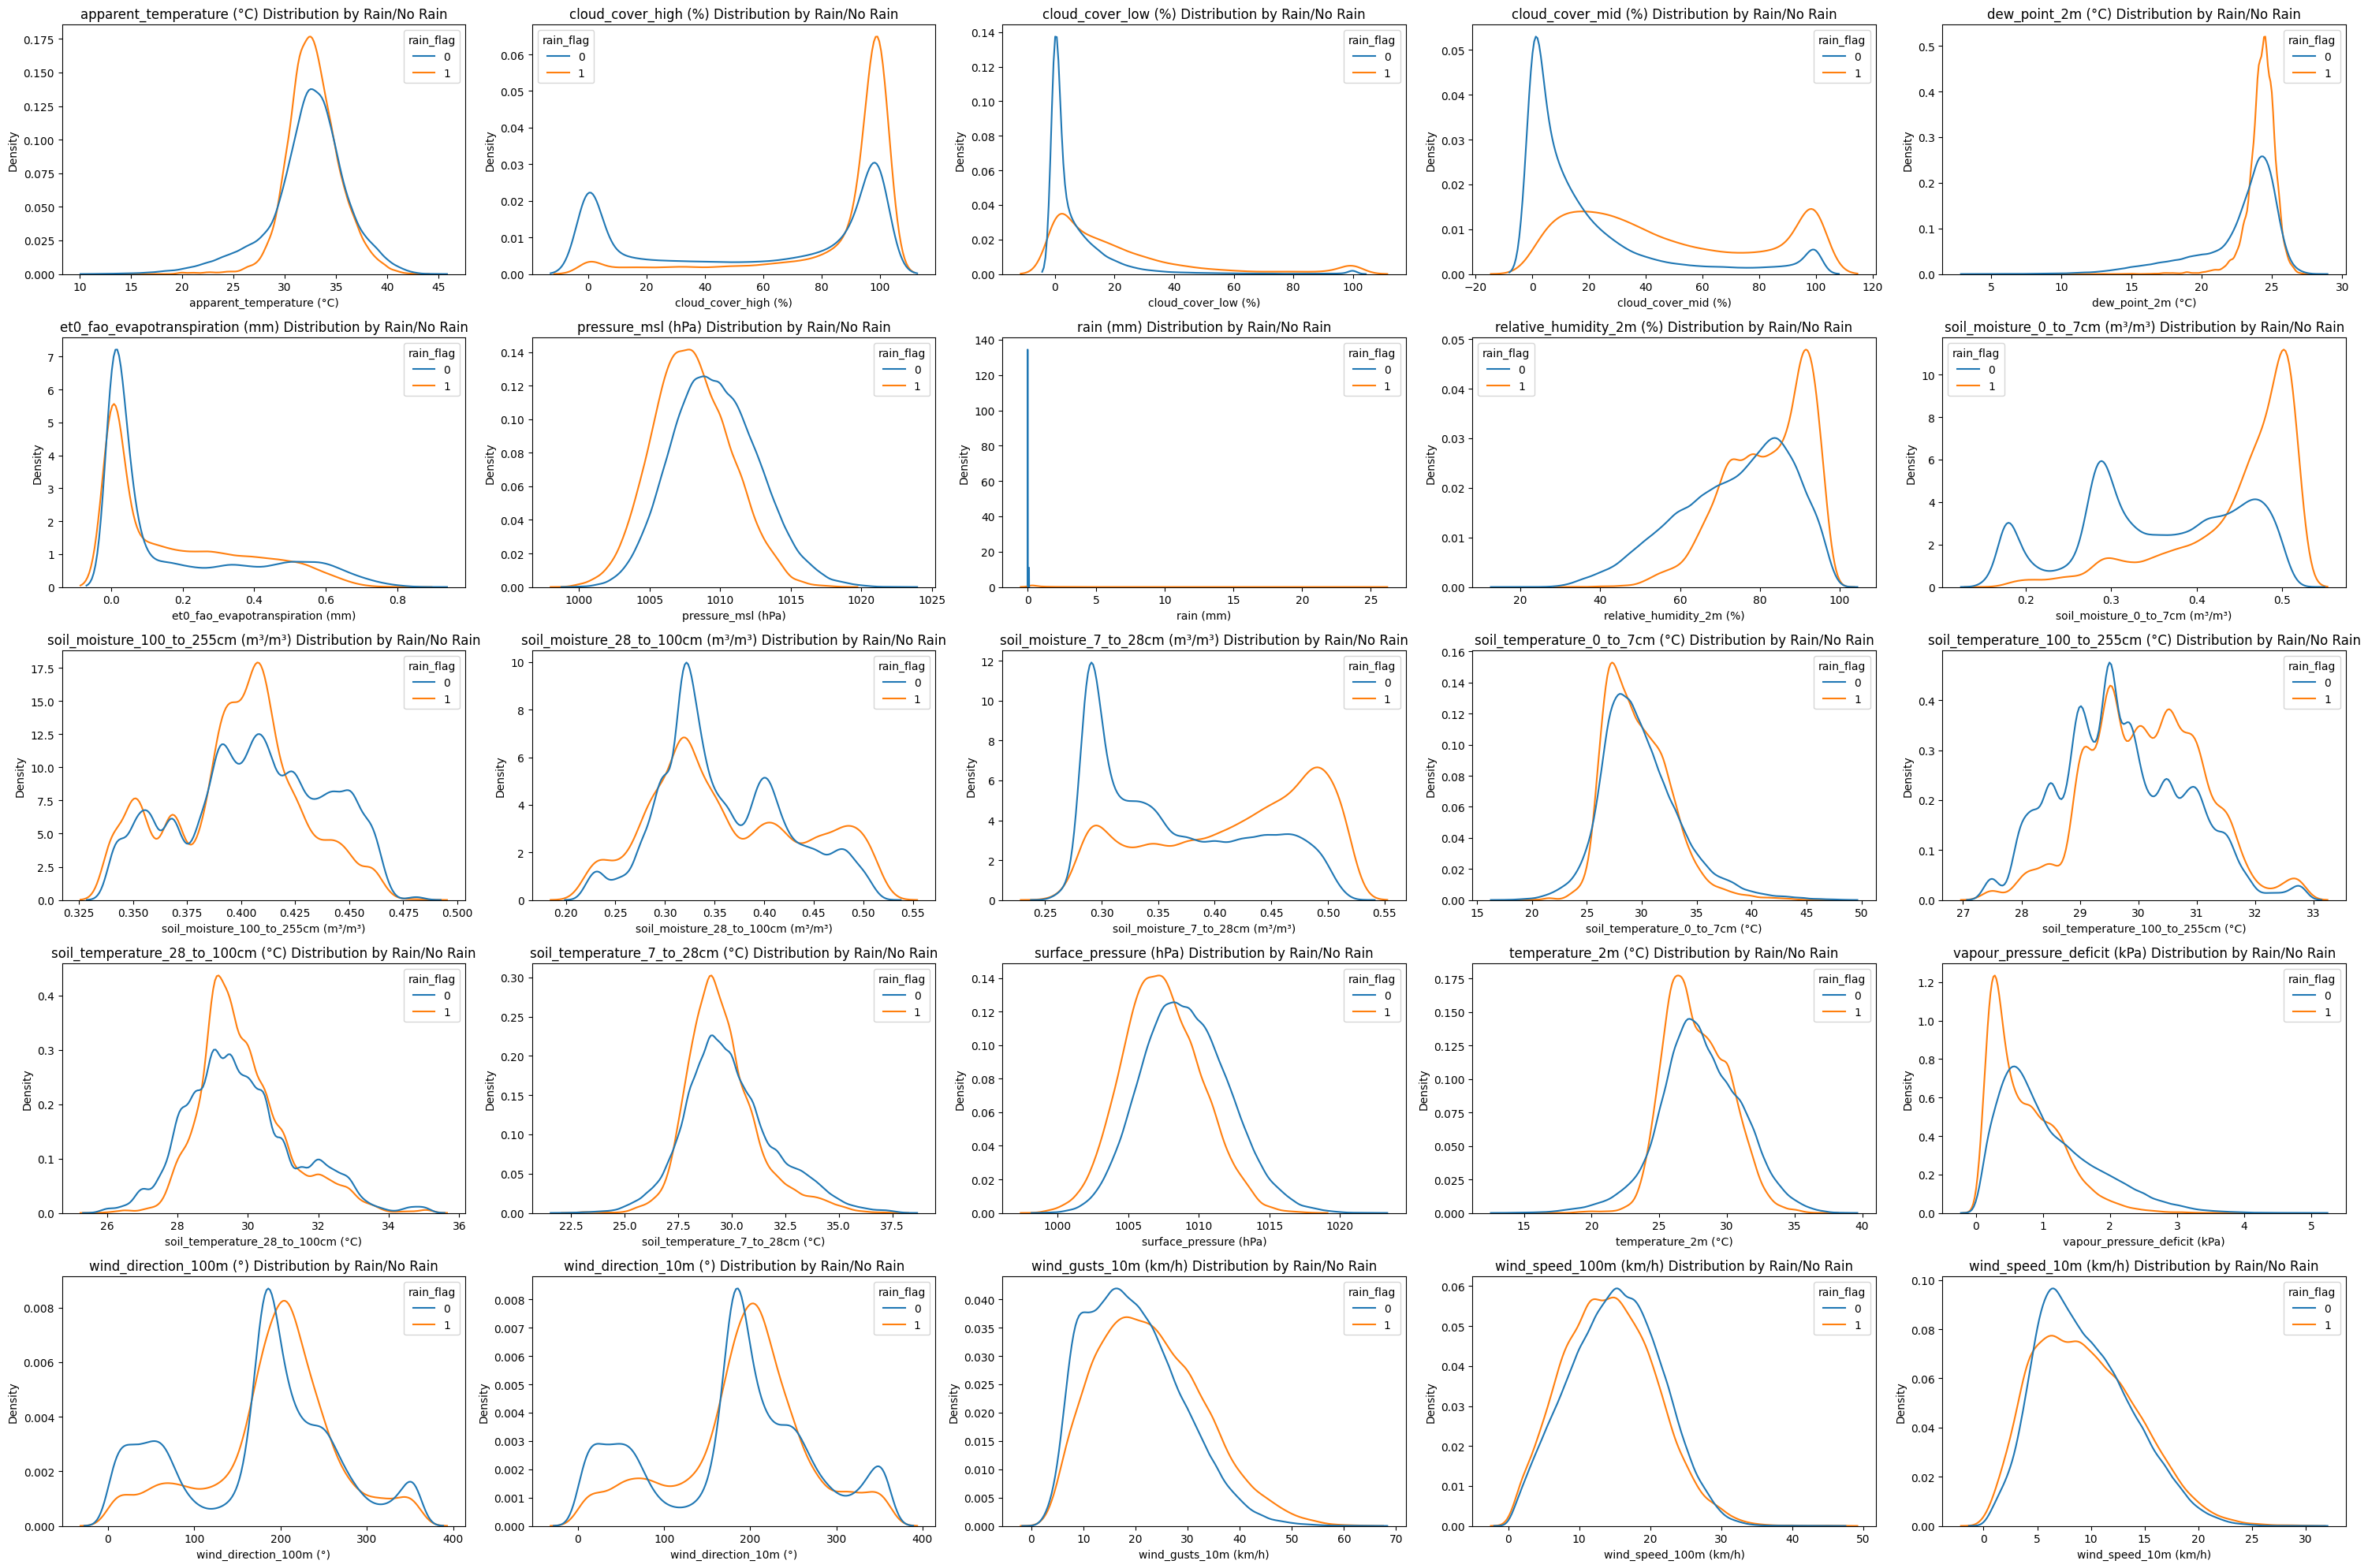

In [18]:
n_cols = 5
n_rows = math.ceil(len(numeric_cols) / n_cols)

plt.figure(figsize=(6*n_cols, 4*n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.kdeplot(data=df_train, x=col, hue='rain_flag', common_norm=False)
    plt.title(f"{col} Distribution by Rain/No Rain")

plt.tight_layout()
plt.show()

### Boxplots

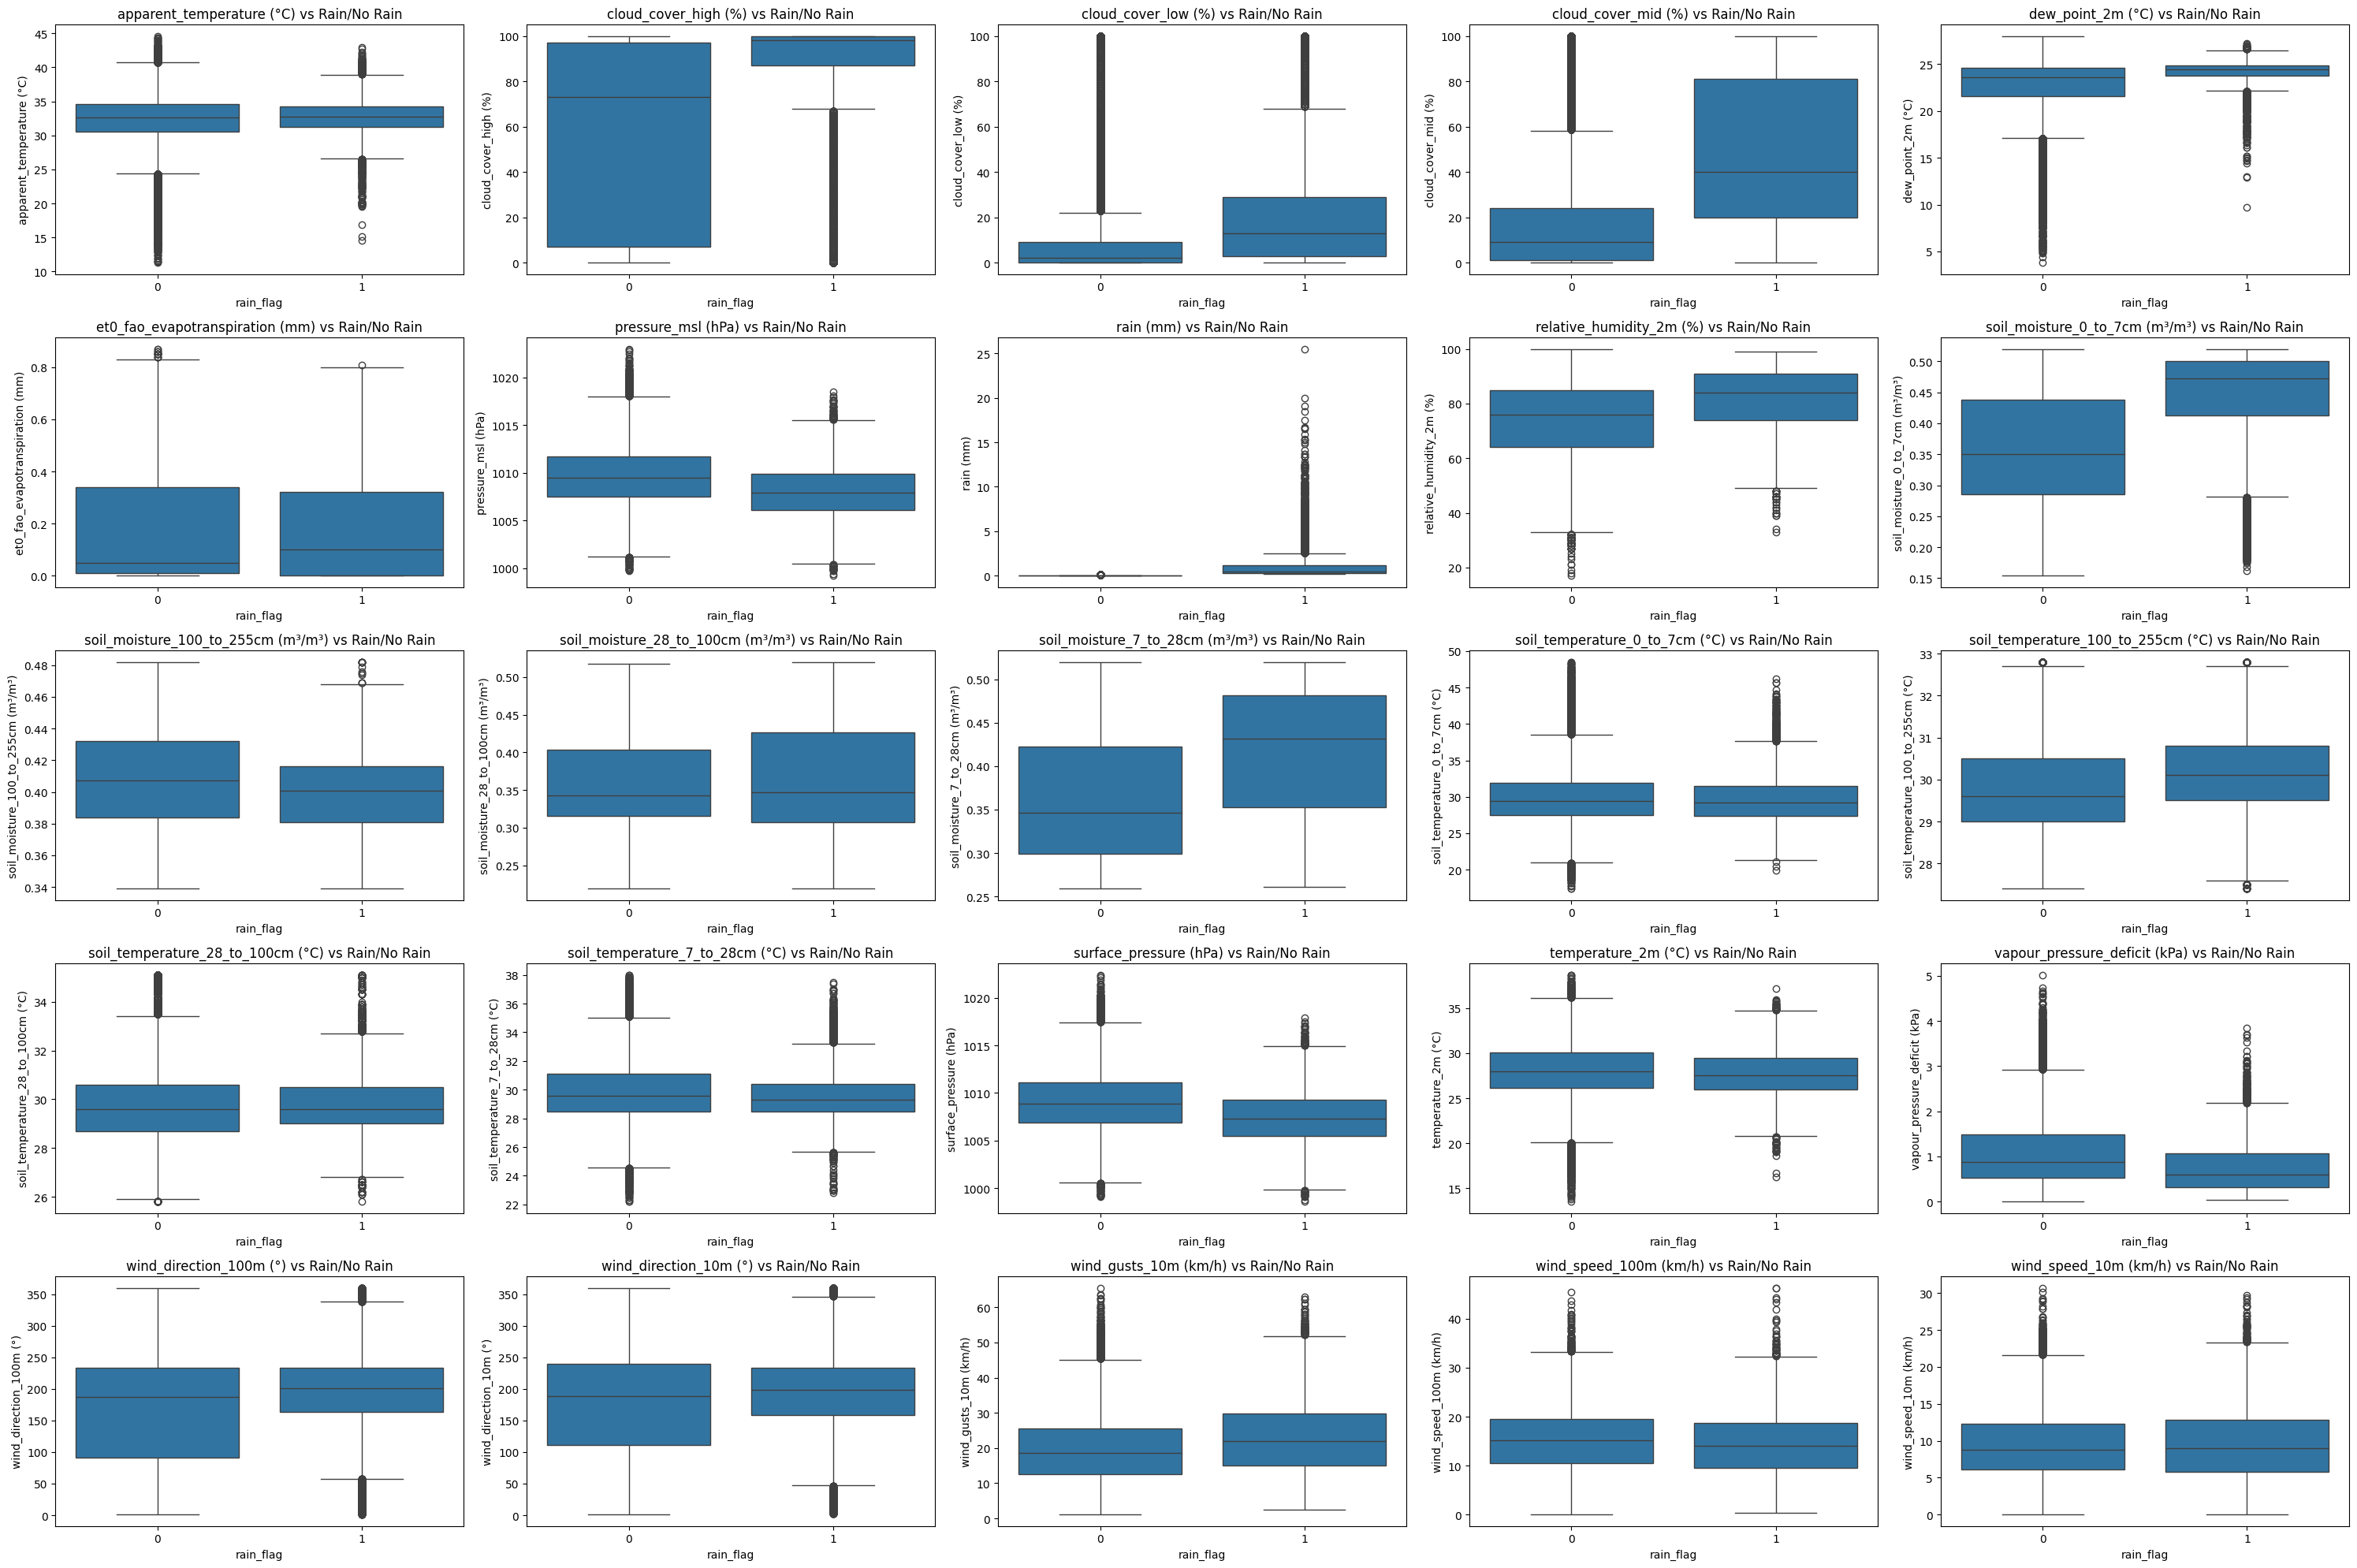

In [19]:
n_cols = 5
n_rows = math.ceil(len(numeric_cols) / n_cols)

plt.figure(figsize=(6*n_cols, 4*n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x='rain_flag', y=col, data=df_train)
    plt.title(f"{col} vs Rain/No Rain")

plt.tight_layout()
plt.show()

## Correlation Matrix

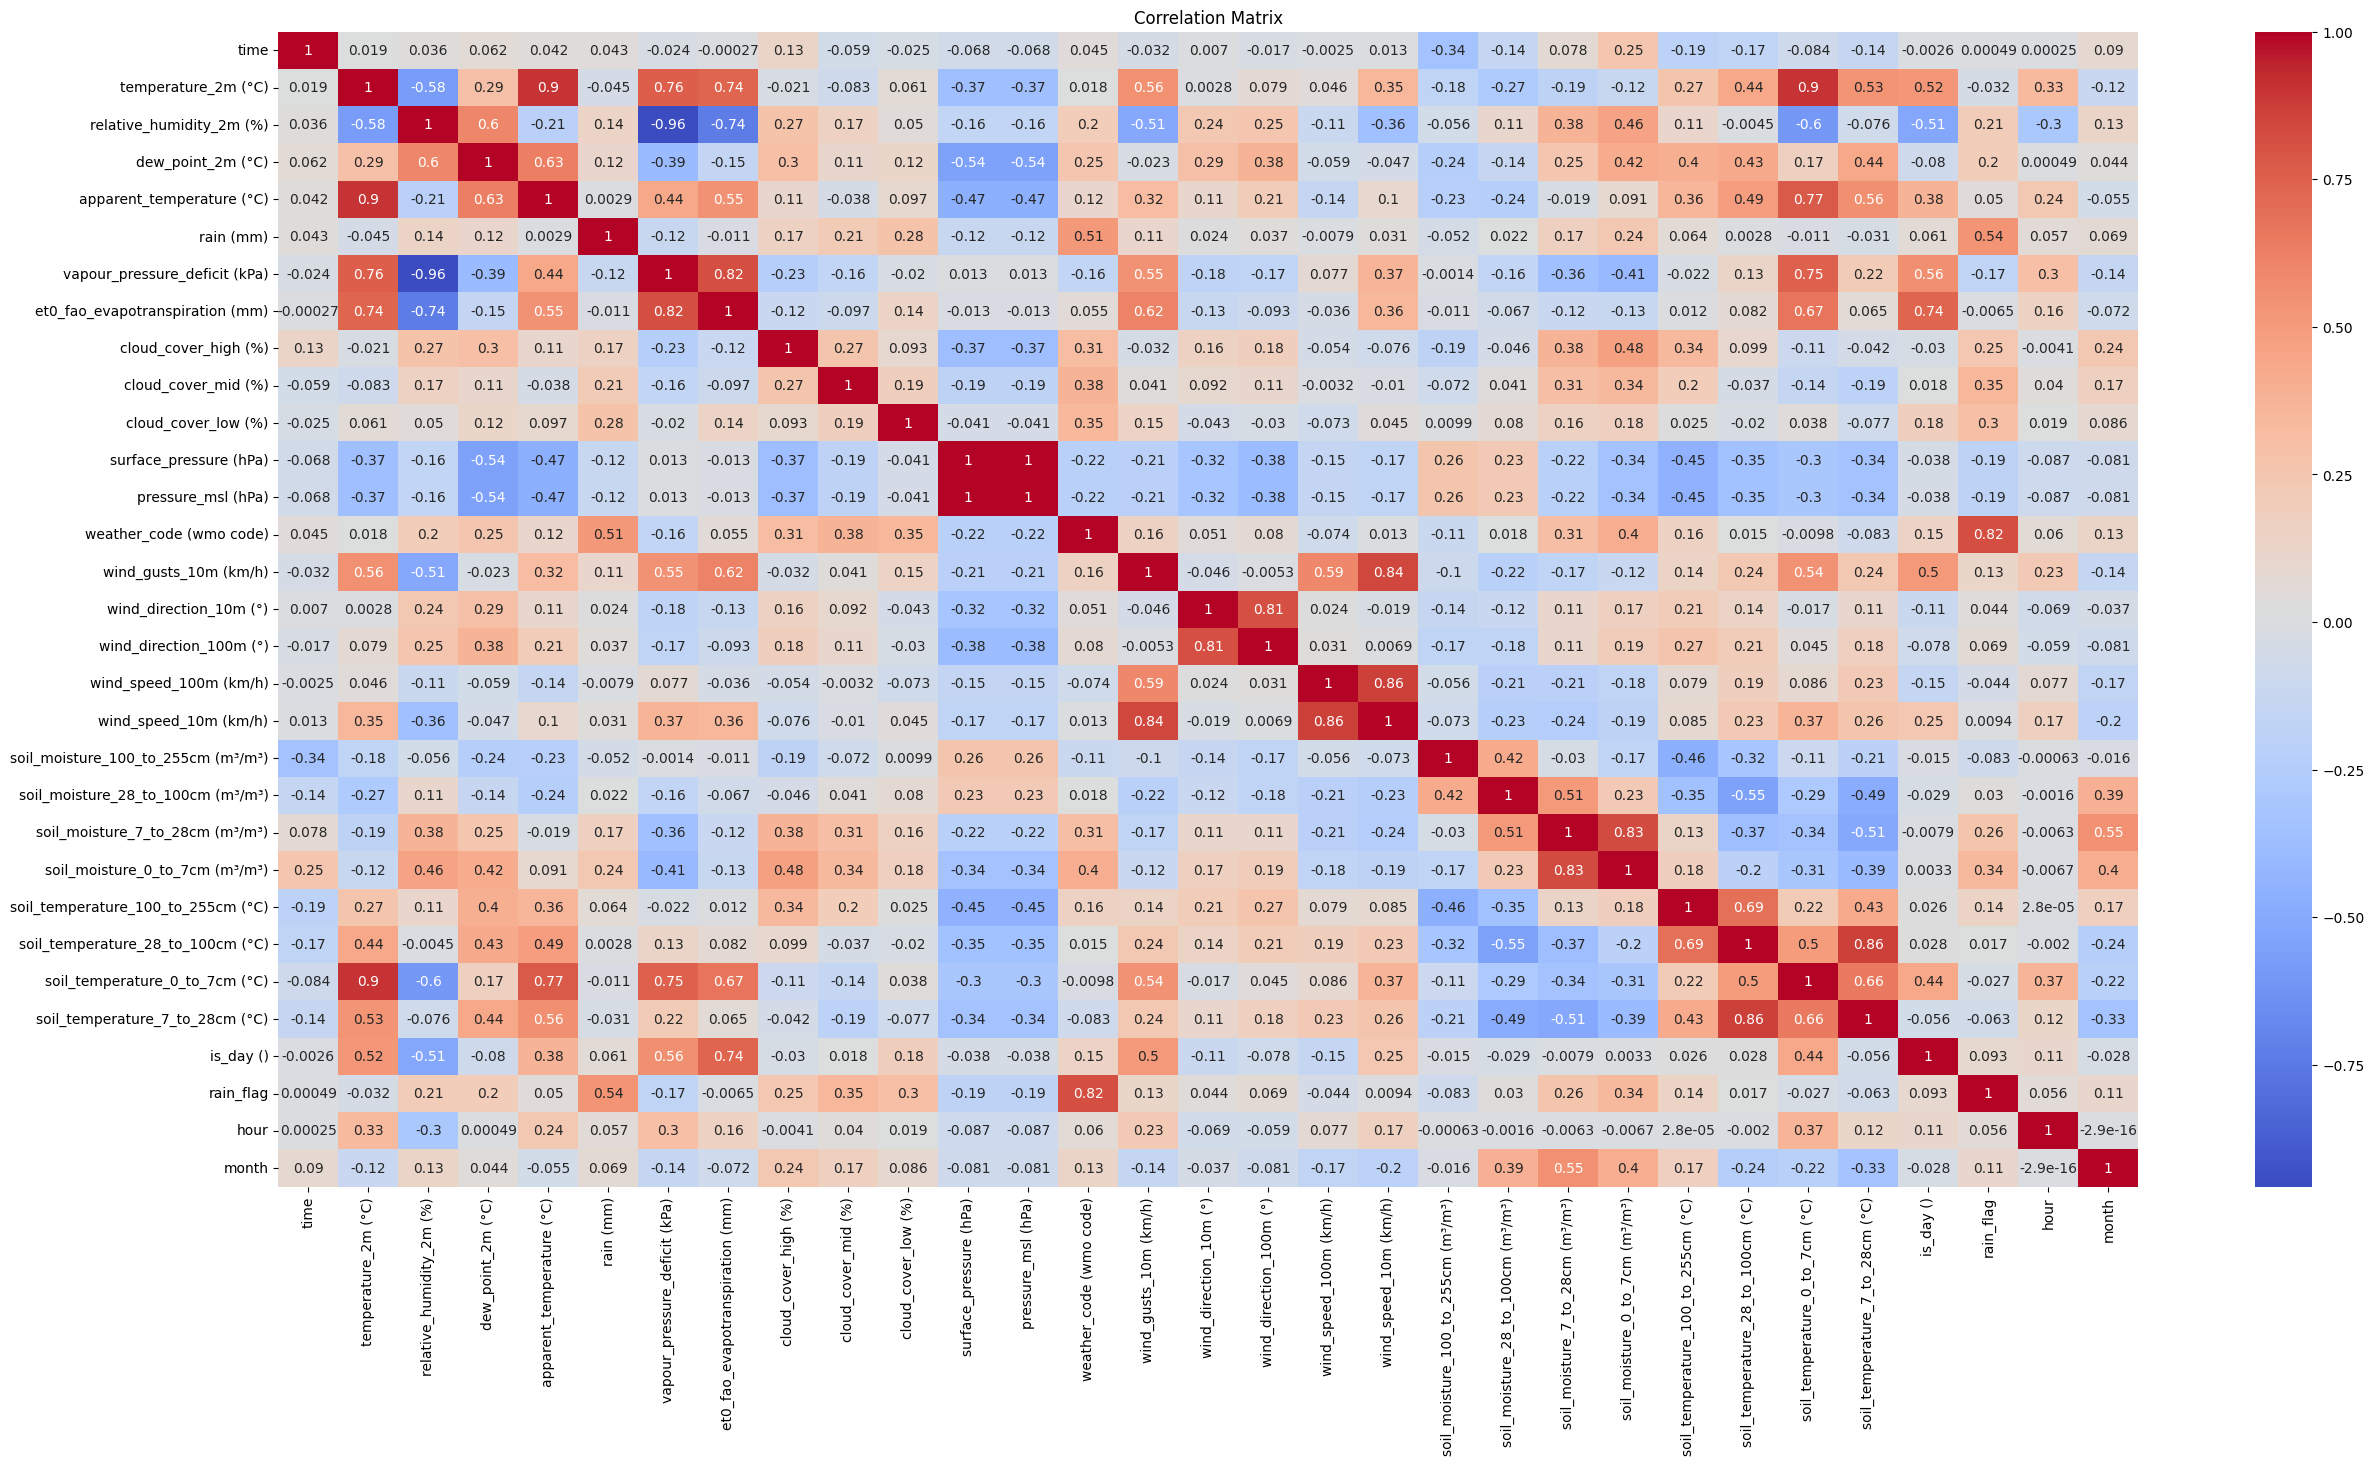

In [20]:
corr = df_train.corr()
plt.figure(figsize=(30,15))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Correlate With Label Check

In [21]:
numeric_cols = df_train.select_dtypes(include='number').columns.tolist()
# Remove the target column if it’s included
numeric_cols = [col for col in numeric_cols if col != 'rain_flag']

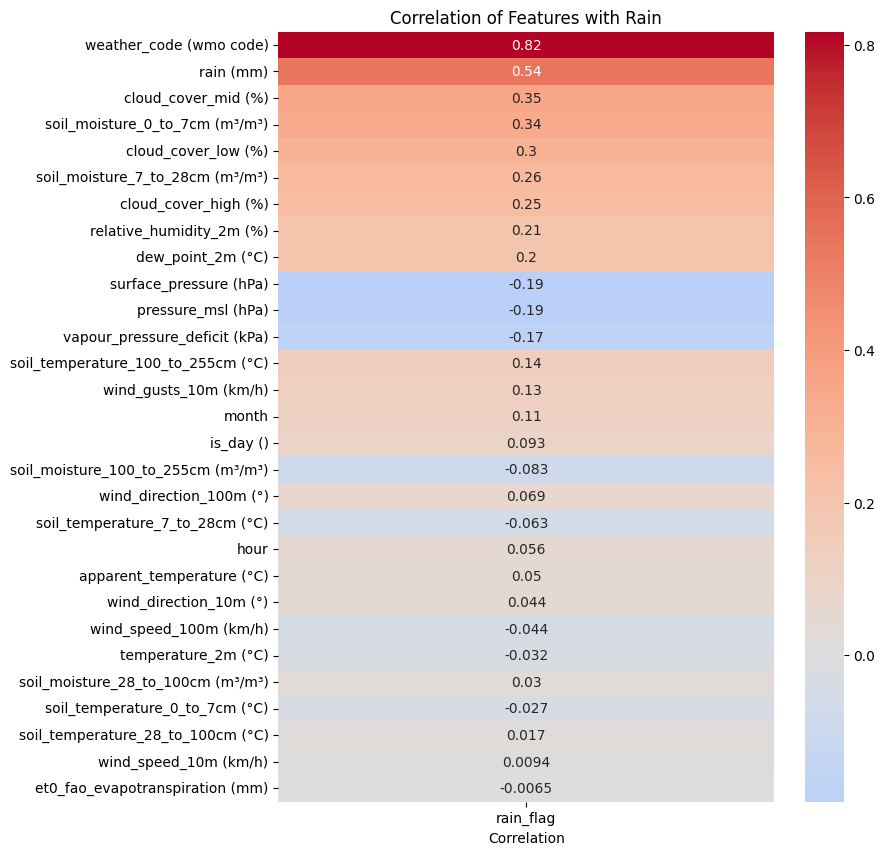

In [22]:
# Compute correlation with target
corr_with_target = df_train[numeric_cols + ['rain_flag']].corr()['rain_flag'].drop('rain_flag')

# Sort by absolute correlation
corr_with_target = corr_with_target.reindex(corr_with_target.abs().sort_values(ascending=False).index)

plt.figure(figsize=(8,10))
sns.heatmap(corr_with_target.to_frame(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation of Features with Rain")
plt.xlabel("Correlation")
plt.show()

# Bias Visualization Using Fairlearn (Pre-training)

- Pre-training selection rate is the fraction of positive labels (1) in each bin, showing how the positive labels are distributed across the bins.

In [ ]:
# !pip install fairlearn

In [49]:
from fairlearn.metrics import MetricFrame, selection_rate

sensitive_feature_binned = pd.qcut(
    df_train['temperature_2m (°C)'],
    q=5,  # split into 5 quantiles
    labels=["Q1","Q2","Q3","Q4","Q5"]
)

mf_data = MetricFrame(
    metrics={"selection_rate": selection_rate},
    y_true=df_train["rain_flag"],  # target for the full dataset
    y_pred=df_train["rain_flag"],  # use labels itself to see distribution
    sensitive_features=sensitive_feature_binned
)

mf_data.by_group

,selection_rate
temperature_2m (°C),
Q1,0.145412
Q2,0.183238
Q3,0.143829
Q4,0.159535
Q5,0.094758


In [48]:
from fairlearn.metrics import MetricFrame, selection_rate

def plot_selection_rate_all_features_grid(df, target_col, n_bins=5, n_cols=5):
    numeric_cols = df.select_dtypes(include='number').columns.drop(target_col)
    n_rows = math.ceil(len(numeric_cols) / n_cols)

    plt.figure(figsize=(6*n_cols, 4*n_rows))

    for i, col in enumerate(numeric_cols, 1):
        # Bin the feature
        binned = pd.qcut(df[col], q=n_bins, duplicates='drop', labels=[f"Q{j}" for j in range(1, n_bins+1)])

        # Compute pre-training selection rate
        mf = MetricFrame(
            metrics={"selection_rate": selection_rate},
            y_true=df[target_col],
            y_pred=df[target_col],  # use labels itself
            sensitive_features=binned
        )
        df_metrics = mf.by_group.reset_index()
        df_metrics.rename(columns={col: 'feature_bin'}, inplace=True)

        # Plot in grid
        plt.subplot(n_rows, n_cols, i)
        sns.barplot(x='feature_bin', y='selection_rate', data=df_metrics)
        plt.title(f"{col} Selection Rate")
        plt.xlabel("Bin")
        plt.ylabel("Fraction of Positive Labels")
        plt.ylim(0, 0.5)

    plt.tight_layout()
    plt.show()

In [46]:
df_for_plot = df_train.drop(columns=["time",
                                     "rain (mm)",
                                     "weather_code (wmo code)",
                                     "cloud_cover_low (%)",
                                     "is_day ()",
                                     "hour",
                                     "month"])

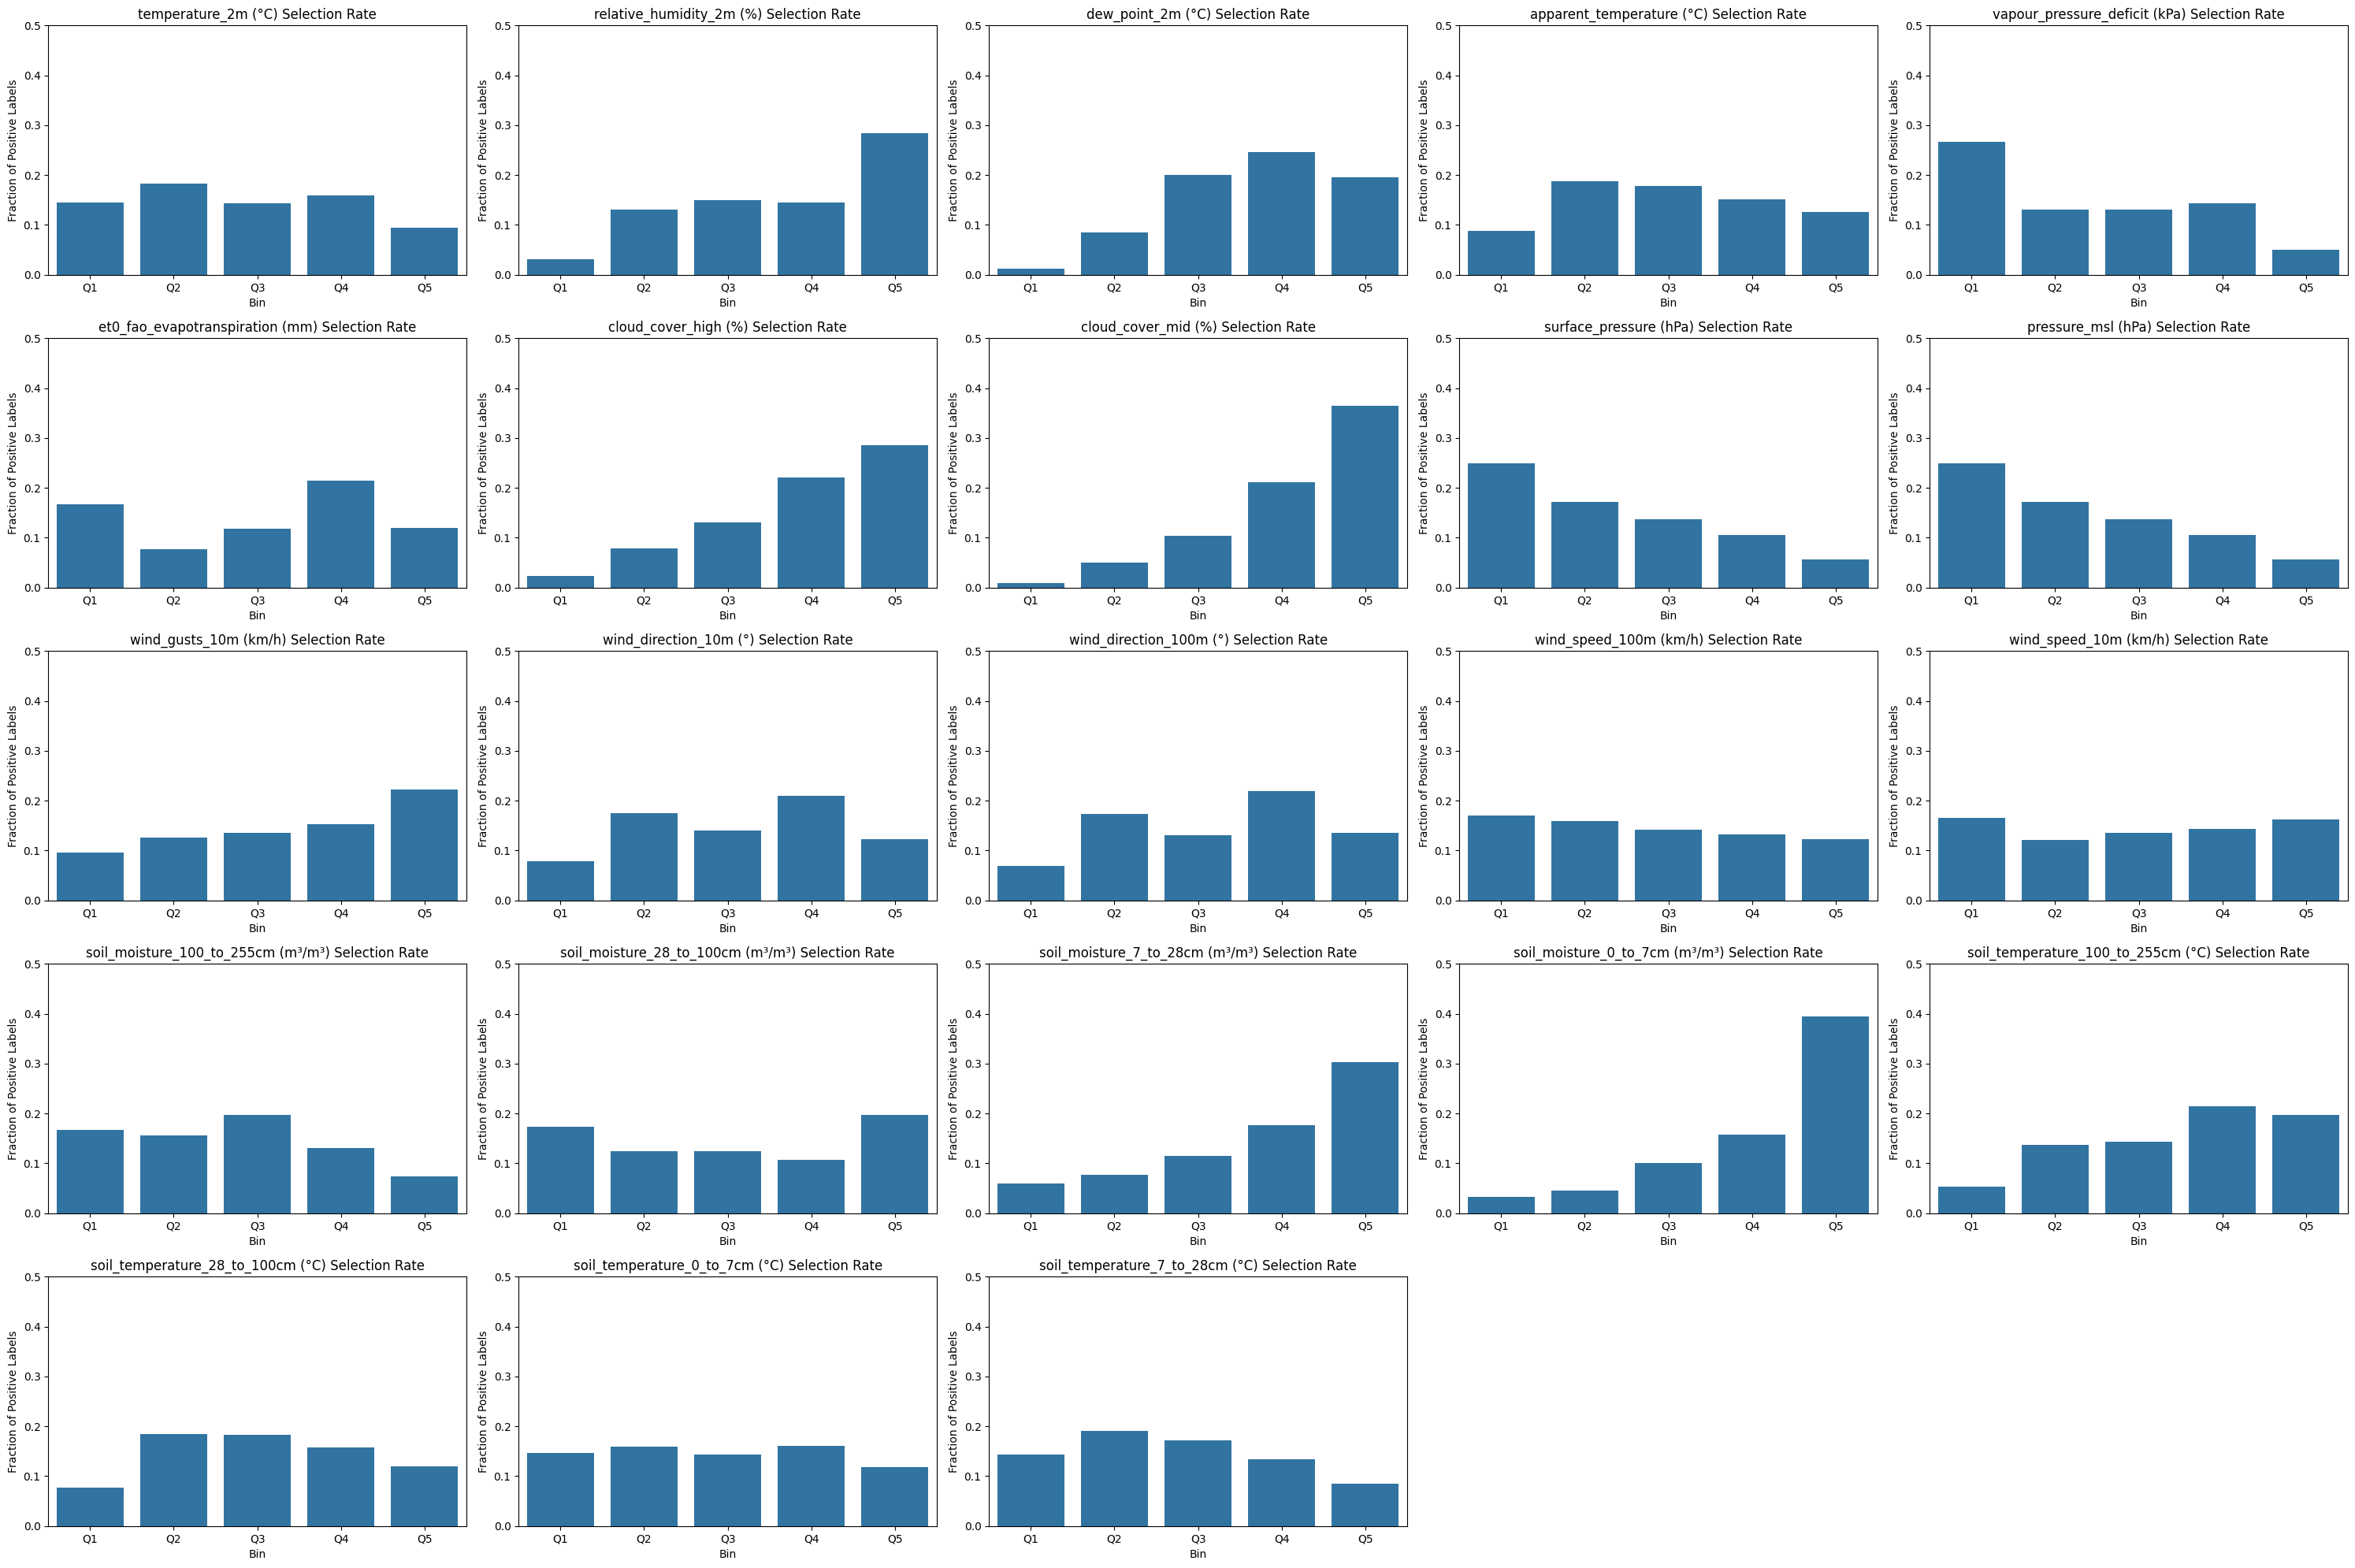

In [47]:
plot_selection_rate_all_features_grid(df_for_plot, target_col="rain_flag", n_bins=5, n_cols=5)

- From the Fairlearn results, some features like relative humidity, high cloud cover, mid cloud cover, surface pressure, etc. have bins where the rain label appears much more often than in other bins. This means the data is not evenly balanced across those feature ranges.

- Also, the rain label itself is imbalanced (there are many more “no rain” samples). Because of this, the model can learn patterns that favor the majority class and may not predict the rain class well, especially in certain feature groups.

- To reduce this problem, I use class weighting (like scale_pos_weight in XGBoost). This gives more importance to the minority class (rain) during training.